# DC LOSS EFFECIENCY CURVE


=== DC MACHINE LOSSES & EFFICIENCY CURVE SIMULATOR ===
From DC-machines.pdf (UNIT-1) - Swinburne's Test

Enter Armature Resistance Ra (Ω)   [example: 0.5]: 0.6
Enter Constant Losses (Iron + Mech + Shunt) (W) [exxample: 800]: 900
Enter Rated Voltage (V)    [example: 230]: 240
Enter Full Load Current (A)  [exxample: 50]: 60

LOSSES & EFFICIENCY RESULTS
Constant Losses (P_const)     = 900 W
Armature Resistance (Ra)      = 0.6 Ω
Maximum Efficiency            = 80.64 %
At Output Power               = 7515 W


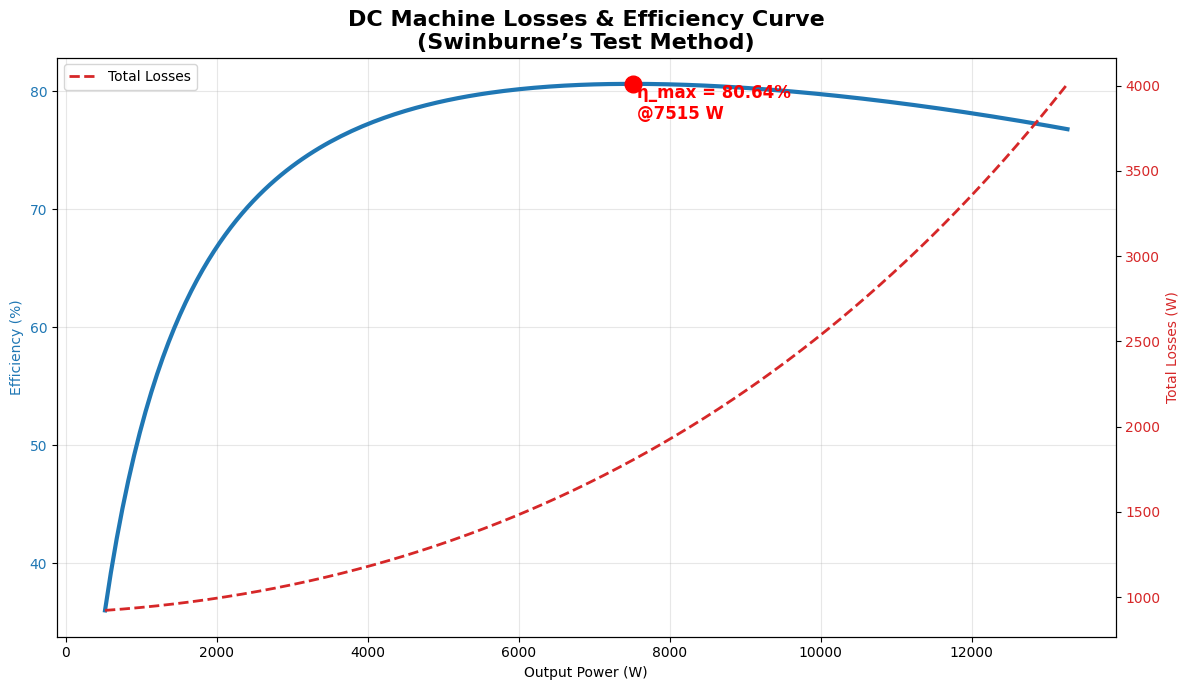

Plot generated successfully!


In [1]:

import numpy as np
import matplotlib.pyplot as plt

print("=== DC MACHINE LOSSES & EFFICIENCY CURVE SIMULATOR ===")
print("From DC-machines.pdf (UNIT-1) - Swinburne's Test\n")

# ====================== USER INPUTS ======================
Ra = float(input("Enter Armature Resistance Ra (Ω)   [example: 0.5]: "))
P_const = float(input("Enter Constant Losses (Iron + Mech + Shunt) (W) [exxample: 800]: "))
V = float(input("Enter Rated Voltage (V)    [example: 230]: "))
I_full = float(input("Enter Full Load Current (A)  [exxample: 50]: "))

# Load percentages from 10% to 120%
load_percent = np.linspace(10, 120, 200)
load_fraction = load_percent / 100

# ====================== CALCULATIONS ======================
I_a = I_full * load_fraction                     # Armature current at different loads
P_variable = I_a**2 * Ra                         # Variable loss = I_a² Ra
P_total_loss = P_const + P_variable
P_input = V * I_a                                # Input power
P_output = P_input - P_total_loss                # Output power
efficiency = (P_output / P_input) * 100          # Efficiency in %

# Find maximum efficiency point
idx_max = np.argmax(efficiency)
P_out_max_eta = P_output[idx_max]
eta_max = efficiency[idx_max]

# ====================== DISPLAY RESULTS ======================
print("\n" + "="*70)
print("LOSSES & EFFICIENCY RESULTS")
print("="*70)
print(f"Constant Losses (P_const)     = {P_const:.0f} W")
print(f"Armature Resistance (Ra)      = {Ra} Ω")
print(f"Maximum Efficiency            = {eta_max:.2f} %")
print(f"At Output Power               = {P_out_max_eta:.0f} W")
print("="*70)

# ====================== PLOT ======================
fig, ax1 = plt.subplots(figsize=(12, 7))

color1 = 'tab:blue'
ax1.set_xlabel('Output Power (W)')
ax1.set_ylabel('Efficiency (%)', color=color1)
ax1.plot(P_output, efficiency, color=color1, linewidth=3, label='Efficiency Curve')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Mark maximum efficiency point
ax1.plot(P_out_max_eta, eta_max, 'ro', markersize=12, label='Maximum Efficiency Point')
ax1.text(P_out_max_eta + 50, eta_max - 3, f'η_max = {eta_max:.2f}%\n@{P_out_max_eta:.0f} W',
         fontsize=12, color='red', fontweight='bold')

ax1.set_title('DC Machine Losses & Efficiency Curve\n(Swinburne’s Test Method)',
              fontsize=16, fontweight='bold')

# Secondary y-axis for losses (optional but very good)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Total Losses (W)', color=color2)
ax2.plot(P_output, P_total_loss, color=color2, linestyle='--', linewidth=2, label='Total Losses')
ax2.tick_params(axis='y', labelcolor=color2)

fig.tight_layout()
plt.legend(loc='upper left')
plt.show()

print("Plot generated successfully!")